In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from astropy.io import ascii

# Load HPIC (pipe-delimited)
hpic = ascii.read('input/HPIC_LC4_combined_d50.txt', format='csv', delimiter='|')
hpic_ra  = np.array(hpic['ra'],  dtype=float)
hpic_dec = np.array(hpic['dec'], dtype=float)

# Load EMC — deduplicate to one row per host star
emc = pd.read_csv('exo-mercat.csv')
emc_hosts = emc.drop_duplicates(subset='host')
emc_ra  = emc_hosts['main_id_ra'].values.astype(float)
emc_dec = emc_hosts['main_id_dec'].values.astype(float)

print(f"HPIC stars: {len(hpic_ra)}")
print(f"EMC unique hosts: {len(emc_ra)}")

HPIC stars: 14571
EMC unique hosts: 14569


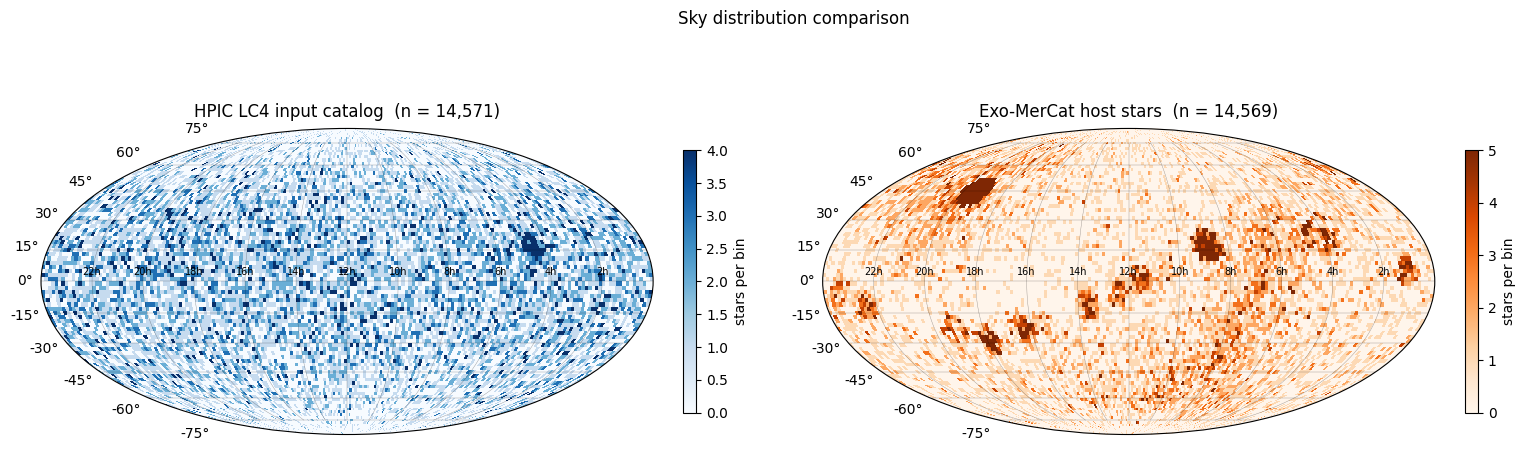

In [5]:
def sky_hist(ra_deg, dec_deg, n_ra=180, n_dec=90):
    # Negate (180 - ra) so RA increases left without needing invert_xaxis,
    # which is unsupported on geographic projections.
    ra_rad  = np.radians(180.0 - ra_deg)          # [0,360] → [π,−π], 12h at centre
    dec_rad = np.radians(dec_deg)
    ra_edges  = np.linspace(-np.pi, np.pi,  n_ra  + 1)
    dec_edges = np.linspace(-np.pi/2, np.pi/2, n_dec + 1)
    H, _, _ = np.histogram2d(ra_rad, dec_rad, bins=[ra_edges, dec_edges])
    ra_c  = 0.5 * (ra_edges[:-1]  + ra_edges[1:])
    dec_c = 0.5 * (dec_edges[:-1] + dec_edges[1:])
    return H.T, ra_c, dec_c


H_hpic, ra_c, dec_c = sky_hist(hpic_ra, hpic_dec)
H_emc,  _,    _     = sky_hist(emc_ra,  emc_dec)
RA, DEC = np.meshgrid(ra_c, dec_c)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), subplot_kw={'projection': 'mollweide'})

datasets = [
    (H_hpic, 'HPIC LC4 input catalog', 'Blues',  len(hpic_ra)),
    (H_emc,  'Exo-MerCat host stars',   'Oranges', len(emc_ra)),
]

# With negated RA, ticks run 22h → 2h left-to-right (RA increases left = astronomical)
RA_TICK_LABELS = ['22h','20h','18h','16h','14h','12h','10h','8h','6h','4h','2h']

for ax, (H, title, cmap, n) in zip(axes, datasets):
    vmax = np.percentile(H[H > 0], 97)
    mesh = ax.pcolormesh(RA, DEC, H, cmap=cmap, vmin=0, vmax=vmax, shading='auto')
    ax.set_title(f'{title}  (n = {n:,})', pad=8)
    ax.set_xticklabels(RA_TICK_LABELS, fontsize=7)
    ax.grid(color='k', linewidth=0.3, alpha=0.4)
    plt.colorbar(mesh, ax=ax, pad=0.04, shrink=0.6, label='stars per bin')

plt.suptitle('Sky distribution comparison', y=1.01)
plt.tight_layout()
plt.show()

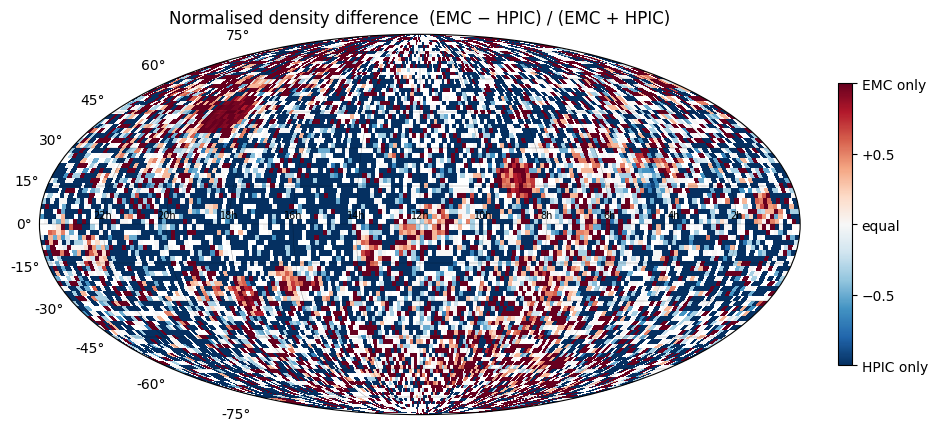

In [6]:
# Normalised density difference: (EMC - HPIC) / (EMC + HPIC)
# +1 = only EMC, -1 = only HPIC, 0 = equal density
total = H_hpic + H_emc
with np.errstate(invalid='ignore', divide='ignore'):
    diff = np.where(total > 0, (H_emc - H_hpic) / total, np.nan)

fig, ax = plt.subplots(1, 1, figsize=(10, 5), subplot_kw={'projection': 'mollweide'})
mesh = ax.pcolormesh(RA, DEC, diff, cmap='RdBu_r', vmin=-1, vmax=1, shading='auto')
ax.set_title('Normalised density difference  (EMC − HPIC) / (EMC + HPIC)', pad=8)
ax.set_xticklabels(['22h','20h','18h','16h','14h','12h','10h','8h','6h','4h','2h'], fontsize=7)
ax.grid(color='k', linewidth=0.3, alpha=0.4)
cb = plt.colorbar(mesh, ax=ax, pad=0.04, shrink=0.6)
cb.set_ticks([-1, -0.5, 0, 0.5, 1])
cb.set_ticklabels(['HPIC only', '−0.5', 'equal', '+0.5', 'EMC only'])
plt.tight_layout()
plt.show()